## Import

In [166]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data loading

In [167]:
try:
    df = pd.read_csv('../data/ml-latest-small/movies.csv')

    if not df.empty:
        print("sikeres beolvasás")
    else :print("nem sikerült beolvasni")
except FileNotFoundError:
    print("Hiba: Nem található a fájl az útvonalban")

sikeres beolvasás


## Data check

In [ ]:
print(df.head(3))

print("info")
print(df.info())

print("Describe")
print(df.describe())

   movieId                    title  \
0        1         Toy Story (1995)   
1        2           Jumanji (1995)   
2        3  Grumpier Old Men (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
info
malac
<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  9742 non-null   int64
 1   title    9742 non-null   str  
 2   genres   9742 non-null   str  
dtypes: int64(1), str(2)
memory usage: 228.5 KB
None
Describe
             movieId
count    9742.000000
mean    42200.353623
std     52160.494854
min         1.000000
25%      3248.250000
50%      7300.000000
75%     76232.000000
max    193609.000000


## Genre split and figure 

{'Adventure': 1263, 'Animation': 611, 'Children': 664, 'Comedy': 3756, 'Fantasy': 779, 'Romance': 1596, 'Drama': 4361, 'Action': 1828, 'Crime': 1199, 'Thriller': 1894, 'Horror': 978, 'Mystery': 573, 'Sci-Fi': 980, 'War': 382, 'Musical': 334, 'Documentary': 440, 'IMAX': 158, 'Western': 167, 'Film-Noir': 87, '(no genres listed)': 34}


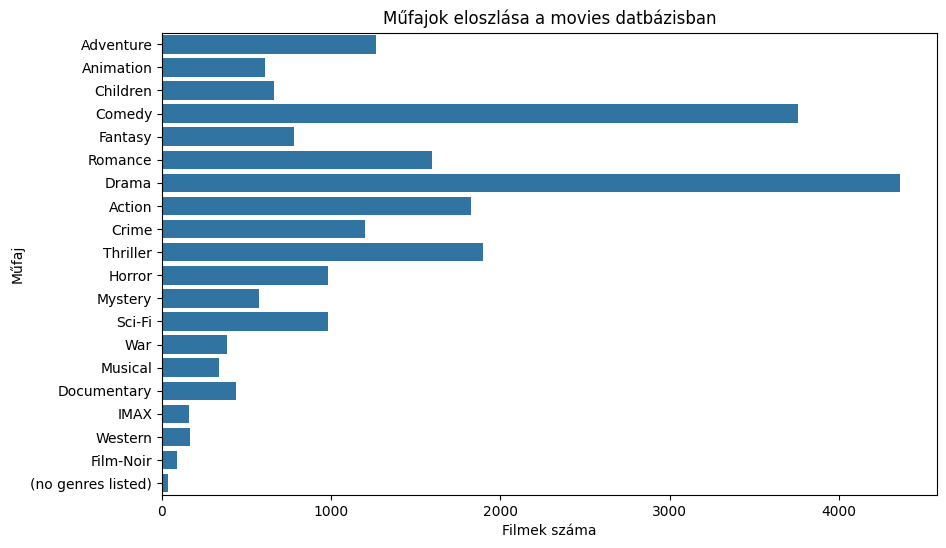

In [169]:
genre_counter = {}

for row in df['genres']:
    genres_list = row.split('|')

    for i in genres_list:
        if i in genre_counter:
            genre_counter[i] += 1
        else:
            genre_counter[i] =1

print(genre_counter)


plt.figure(figsize=(10,6))
sns.barplot(x=genre_counter.values(), y=genre_counter.keys())
plt.title("Műfajok eloszlása a movies datbázisban")
plt.xlabel("Filmek száma")
plt.ylabel("Műfaj")
plt.show()


## Top 10 most common genres

In [170]:
df['genres'] = df['genres'].str.split('|')
#print(df['genres'])
df_exploded = df.explode('genres')

top_10 = df_exploded['genres'].value_counts().head(10)


top_10.to_frame(name='Count')



,Count
genres,
Drama,4361
Comedy,3756
Thriller,1894
Action,1828
Romance,1596
Adventure,1263
Crime,1199
Sci-Fi,980
Horror,978
